In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verify Dataset path

In [3]:
import os

dataset_path = "/content/drive/MyDrive/tomato/train"

print("Dataset path:", os.path.exists(dataset_path))
print("Folders path:", os.listdir(dataset_path))

Dataset path: True
Folders path: ['Tomato___Tomato_mosaic_virus', 'Tomato___Late_blight', 'Tomato___Target_Spot', 'Tomato___Leaf_Mold', 'Tomato___Early_blight', 'Tomato___Bacterial_spot', 'Tomato___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Septoria_leaf_spot']


### Load Dataset

In [4]:
import tensorflow as tf

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

# Load the training dataset from the directory and split it into training and validation sets using an 80-20 split. The images will be resized to 224x224 and loaded in batches of 32.
# The `image_dataset_from_directory` function is a convenient way to load images from a directory and automatically label them based on the folder structure. The `validation_split` parameter specifies the percentage of data to be used for validation, and the `subset` parameter indicates whether the dataset is for training or validation. The `seed` parameter ensures that the data is shuffled in a consistent way, and the `image_size` and `batch_size` parameters specify how the images should be processed and loaded.
# `image_dataset_from_directory` is the easiest dataset loaders in TensorFlow, it automatically labels the images based on the folder structure and splits the data into training and validation sets. It also allows you to specify the image size and batch size for loading the data.
train_ds= tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2, # 20% data for validation
    subset="training", # training data
    seed= 42, # random seed for shuffling and splitting the data
    image_size=IMAGE_SIZE, # resize images to 224x224
    batch_size=BATCH_SIZE # batch size means how many samples will be propagated through the network at once
)

# Load the validation dataset from the directory and split it into training and validation sets using an 80-20 split. The images will be resized to 224x224 and loaded in batches of 32.
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation", 
    seed= 42, 
    image_size=IMAGE_SIZE, 
    batch_size=BATCH_SIZE 
)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.


### Inspect Class names

example:
 
['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']

then: 
- 0 → Early blight
- 1 → Late blight
- 2 → healthy

In [5]:
class_names= train_ds.class_names
print("Class names:", class_names)

Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


### Looking at one batch

A tensor shape:

(batch, height, width, channels)

So:
- 32 images
- each 224 × 224
- 3 channels (RGB)

so this is real tensorflow tensor

In [6]:
# Check the shape of the image and label batches to ensure that the 
# data is being loaded correctly. The `take(1)` method is used to 
# take one batch of data from the training dataset, and the shapes 
# of the image and label batches are printed to the console. 
# This is a common step to verify that the data is being loaded and 
# processed correctly before training a model.
for image_batch, label_batch in train_ds.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


### Speedup input pipeline

- .cache() ->
       Keeps dataset in memory after first epoch.
       Less disk reading.
- .shuffle(1000) ->
       Mixes images randomly.
       Very important — otherwise batches may contain only one class.
- .prefetch() ->
       Prepares the next batch while GPU trains on the current batch.
       Better throughput.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE # AUTOTUNE is a constant in TensorFlow that represents an automatic tuning option for data loading and preprocessing. When you set the `buffer_size` parameter to `AUTOTUNE`, TensorFlow will automatically determine the optimal buffer size for prefetching data based on the available system resources and the characteristics of the dataset. This can help improve the performance of data loading and preprocessing by allowing TensorFlow to efficiently manage memory and CPU resources.

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

### Normalize pixel values

normal pixel for imgaes : 0 to 255

but neural networks usually learn better with: 0 to 1

Why 1./255?

Each pixel becomes:

x(new) = x/255

That means:

- 0 → 0.0
- 255 → 1.0

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255) # Rescaling is a common preprocessing step in image data pipelines, where the pixel values of the images are scaled to a specific range. In this case, the `Rescaling` layer is used to scale the pixel values to the range [0, 1] by dividing each pixel value by 255 (the maximum pixel value for an 8-bit image). This normalization step can help improve the performance of machine learning models by ensuring that the input data is on a consistent scale, which can lead to faster convergence during training and better overall model performance.

### Build the CNN

- Conv2D -> learns visual patterns
   - edges
   - textures
   - leaf spots
   - lesion shapes

- MaxPooling
   Reduces spatial size.
   Example:

         224×224 → 112×112

   Benefits:
   - fewer parameters
   - faster training
   - better abstraction
- Flatten
   - Converts 3D feature maps into 1D vector before dense layers.
- Final Dense layer
   - Outputs logits.
   - If you have 3 diseases:
         [2.1, -0.7, 1.3]
   - Higher number = stronger model confidence.

In [9]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    normalization_layer,

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # The `Conv2D` layer is responsible for feature extraction, while the `MaxPooling2D` layer 
    # helps to downsample the feature maps and reduce the number of parameters in the model, 
    # which can improve generalization and reduce overfitting.
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(), # The Flatten layer is a crucial component in a convolutional 
    #neural network (CNN) architecture, as it bridges the gap between the convolutional 
    #layers and the fully connected layers. By converting the 2D feature maps into a 1D vector, 
    #it enables the model to utilize the extracted features for classification or regression 
    #tasks in the subsequent dense layers.

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes) # if use softmax activation function, 
    #the output will be a probability distribution over the classes, which is 
    #useful for multi-class classification problems. If you use a linear activation 
    #function (or no activation function), the output will be raw logits, which can be 
    #used with certain loss functions like `SparseCategoricalCrossentropy` with 
    #`from_logits=True`.

])

### Compile model

- optimizer: adam updates weights using gradients.
- loss: measures prediction error
- from_logits= true -> final layer dosen't use softmax So,Tensorflow applies correct math internally

In [10]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### View Model Architecture

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train
What happens during training?

For every batch:
   - forward pass
   - compute loss
   - backpropagation
   - update weights

In [12]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=10
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1609s 1s/step - accuracy: 0.5602 - loss: 1.2448 - val_accuracy: 0.7620 - val_loss: 0.6831
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8117 - loss: 0.5428 - val_accuracy: 0.8195 - val_loss: 0.5106
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8814 - loss: 0.3479 - val_accuracy: 0.8320 - val_loss: 0.4843
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.9100 - loss: 0.2577 - val_accuracy: 0.8415 - val_loss: 0.4900
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9398 - loss: 0.1760 - val_accuracy: 0.8630 - val_loss: 0.4419
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9605 - loss: 0.1151 - val_accuracy: 0.8710 - val_loss: 0.4385
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9657 - loss: 0.0960 - val_accuracy: 0.8510 - val_loss: 0.5389
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9785 - loss: 0.0645 - 

### Evaluate

In [13]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8690 - loss: 0.5921
Validation Loss: 0.5921451449394226
Validation Accuracy: 0.8690000176429749


### Predict one Image

Why softmax here?
Training used logits.
For human-readable probabilities we convert logits → probabilities.

In [14]:
import os
import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

Available images in test directory: ['0a2726e0-3358-4a46-b6dc-563a5a9f2bdf___RS_Erly.B 7860.JPG', '0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555.JPG', '0a3f65fc-ef1c-4aed-b235-46bae4e5c0e7___GHLB2 Leaf 9065.JPG', '0ab9c705-f29e-45ac-b786-9549b3c38f16___GCREC_Bact.Sp 3223.JPG']
Using:  /content/drive/MyDrive/tomato/val/0ab9c705-f29e-45ac-b786-9549b3c38f16___GCREC_Bact.Sp 3223.JPG


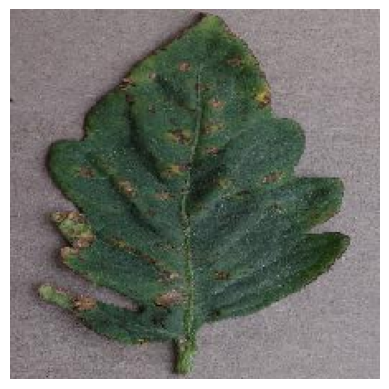

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted: Bacterial spot
Confidence: 67.77%


In [20]:
test_dir = "/content/drive/MyDrive/tomato/val"

images = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Available images in test directory:", images)

img_path = os.path.join(test_dir,random.choice(images))
print("Using: " ,img_path)

img = image.load_img(img_path, target_size=IMAGE_SIZE)

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create a batch dimension

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

print("Predicted:", predicted_class.replace("Tomato___", "").replace("_", " "))
print(f"Confidence: {confidence:.2f}%")
